# <center> Solución de sistemas de ecuaciones lineales

$ \newcommand{\mymatrix}[2]{\left[ \begin{array}{#1} #2\end{array} \right]} $
$ \newcommand{\myvector}[1]{\mymatrix{c}{#1}} $

Cuando hacemos análisis numérico, no solamente nos interesa encontrar una solución a un problema, sino también queremos saber y entender qué tan confiable es esa solución.
En el tema anterior, vimos que las computadoras trabajan con aritmética de punto flotante, y esto significa que casi siempre hay pequeños errores de redondeo o truncamiento en nuestros cálculos.

Ahora, al resolver sistemas de ecuaciones lineales

$$Ax=b$$

donde:

> $A \in \mathbb{R}^{m \times n}$ es una matriz (o transformación) que conozco

> $x \in \mathbb{R}^{n \times 1}$ es mi vector columna incógnita

> $b \in \mathbb{R}^{m \times 1}$ es mi vector columna con datos/mediciones que conozco


quiero poder medir el error en la solución, $e = x_{real} - x_{aprox}$, que es un vector.

Pero entonces, si el error es un vector, **¿cómo lo medimos?** ¿Cómo podemos decir si un error vectorial es _grande_ o _pequeño_?

## Normas vectoriales

Una norma es una función que toma un vector y devuelve un número real no negativo, que representa su 'longitud'. Para que una función sea una norma, debe cumplir cuatro propiedades clave:

* $||x|| \geq 0$ (nunca es negativa)
* $||x|| = 0$ si y solo si $x=0$
* $||\alpha x|| = |\alpha| ||x||$ (saca escalares con valor absoluto)
* $||x+y|| \leq ||x||+||y||$ (desigualdad del triángulo)

Muchas funciones pueden cumplir estas propiedades, pero en la práctica, usamos un conjunto de normas muy útiles llamadas **p-normas**.

### Las tres p-normas principales

In [1]:
import numpy as np
import matplotlib.pyplot as plt

e1 = np.array([0.1, 0.1, 0.1, 0.1, 0.1])
e2 = np.array([0.5, 0, 0, 0, 0])

#### L1 (norma Manhattan)

$
\begin{aligned}
||x||_1 &= \sum |x_i| \\
&= |x_1|+ |x_2| + ... + |x_n|
\end{aligned}
$

In [2]:
# norma L1
L1_e1 = np.linalg.norm(e1, ord=1)
L1_e2 = np.linalg.norm(e2, ord=1)

print(f"Norma L1 de e1: {L1_e1}")
print(f"Norma L1 de e2: {L1_e2}")

Norma L1 de e1: 0.5
Norma L1 de e2: 0.5


#### L2 (norma Euclidiana)

$||x||_2 = \sqrt{\sum x_i^2} = \sqrt{x_1^2 + x_2^2 + ... + x_n^2}$

In [5]:
# norma L2
L2_e1 = np.linalg.norm(e1, ord=2)
L2_e2 = np.linalg.norm(e2, ord=2)

print(f"Norma L2 de e1: {L2_e1:.4f}")
print(f"Norma L2 de e2: {L2_e2:.4f}")

Norma L2 de e1: 0.2236
Norma L2 de e2: 0.5000


#### L-inf (norma infinito o norma del máximo)

$||x||_\infty = \max|x_i|$

In [3]:
# L-inf
Linf_e1 = np.linalg.norm(e1, ord=np.inf)
Linf_e2 = np.linalg.norm(e2, ord=np.inf)

print(f"Norma L-inf de e1: {Linf_e1}")
print(f"Norma L-inf de e2: {Linf_e2}")

Norma L-inf de e1: 0.1
Norma L-inf de e2: 0.5


Una manera de percibir el efecto de una norma es ver la manera en que determinan el _disco_ unitario

$$ \left\{ ||x|| \in \mathbb{R}^n : ||x|| = 1 \right\} $$

In [4]:
# generamos muchos vectores aleatorios
x = np.random.uniform(-1, 1, 10000)
y = np.random.uniform(-1, 1, 10000)
points = np.column_stack((x, y)) # 10000 puntos con coordenadas (x,y), cada fila es un punto

# filtramos los que tienen norma <= 1
def satisfy_norm(orden):
    return np.linalg.norm(points, ord=orden, axis=1) <= 1
l1 = points[satisfy_norm(1)]
l2 = points[satisfy_norm(2)]
linf = points[satisfy_norm(np.inf)]

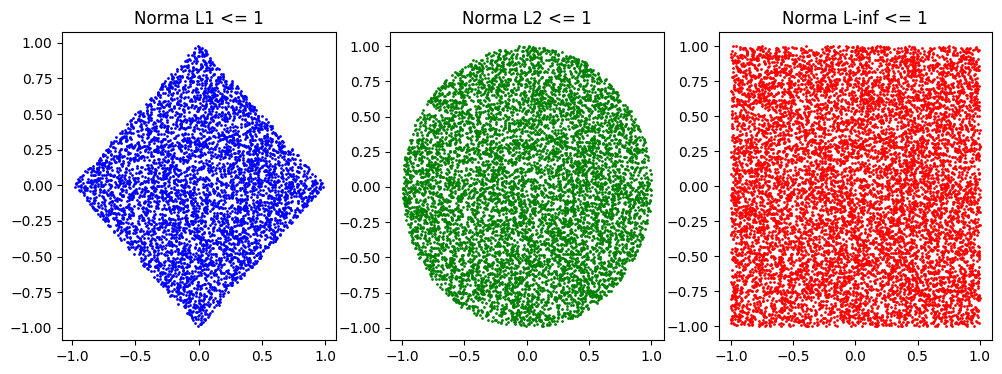

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].scatter(l1[:,0], l1[:,1], s=1, c='blue')
ax[0].set_title('Norma L1 <= 1')
ax[1].scatter(l2[:,0], l2[:,1], s=1, c='green')
ax[1].set_title('Norma L2 <= 1')
ax[2].scatter(linf[:,0], linf[:,1], s=1, c='red')
ax[2].set_title('Norma L-inf <= 1')
plt.show()

<div>
<img src="attachment:38da061f-84a6-4e16-b4e8-6a764e7a56b8.png" width="500"/>
</div>

La elección de la norma depende de qué aspecto del error nos interesa más:

* el error acumulado (L1)
* la magnitud total (L2)
* o el peor caso (L-inf).

### Bueno, ¿y todo esto qué tiene que ver?

Volviendo al tema del sistema $Ax = b$, ahora que ya sabemos medir vectores, queremos saber qué pasa si tengo una pequeña "perturbación" mi vector de entrada $b$ y eso cómo afecta a mi solución $x$.

Dicho esto, un sistema de ecuaciones es sensible (o está **mal condicionado**) si un cambio muy pequeño en el vector $b$ provoca un cambio muy grande en la solución $x$.

#### Ejemplo

Consideraremos un sistema bien condicionado, asociado a una matriz estable $E$, y un sistema mal condicionado, asociado a una matriz sensible $S$.

$$ E = \mymatrix{r}{ 1 & 2 \\ 3 & 4 }$$

$$ S = \mymatrix{r}{ 1 & 1 \\ 1 & 1.0001 }$$

Queremos medir cómo un cambio relativo en la entrada, $\frac{||\delta b||}{||b||}$, se puede traducir en un error relativo en la salida, $\frac{||\delta x||}{||x||}$.

Podemos usar cualquiera de las tres normas que vimos, pues el sistema mal condicionado mostraría una amplificación del error sin importar si usamos la norma L1, L2 o L-inf; pero para este ejemplo usaremos L2 porque es la más conectada con nuestra intuición y con la geometría euclidiana en que opera el sistema.

In [ ]:
import numpy as np

# vector b perfecto
b = np.array([1, 1])

# matrices
E = np.array([[1, 2],
              [3, 4]])

S = np.array([[1, 1],
              [1, 1.0001]])

x_E = np.linalg.solve(E, b)
x_S = np.linalg.solve(S, b)

print("Solución estable:", x_E)
print("Solución sensible:", x_S)

Solución estable: [-1.  1.]
Solución sensible: [1. 0.]


Hasta aquí todo bien, pero ahora vamos a suponer que tenemos un pequeñito error de redondeo al leer el vector $b$, así que le vamos a sumar $0.0001$ a la segunda componente.

In [ ]:
db = np.array([1, 1.0001])

dx_E = np.linalg.solve(E, db)
dx_S = np.linalg.solve(S, db)

print("Nueva solución estable:", dx_E)
print("Nueva solución sensible:", dx_S)

Nueva solución estable: [-0.9999   0.99995]
Nueva solución sensible: [0. 1.]


In [ ]:
# error relativo usando la morma L2
errel_b = np.linalg.norm(db - b) / np.linalg.norm(b)
errel_S = np.linalg.norm(dx_S - x_S) / np.linalg.norm(x_S)

print(f"error relativo de 'b': {errel_b:.6f}")
print(f"error relativo de 'x' para 'S': {errel_S:.6f}")
print(f"el sistema S amplificó el error {errel_S/errel_b:.0f} veces")

error relativo de 'b': 0.000071
error relativo de 'x' para 'S': 1.414214
el sistema S amplificó el error 20000 veces


Vimos que para un par específico de $\frac{||\delta b||}{||b||}$ obtuvimos un factor de amplificación. Lo cual nos lleva a preguntarnos:

**<center>¿Cuál es el máximo factor de amplificación posible que la matriz $A$ puede generar, para cualquier vector $b$?</center>**

## Número de condición

$$ \kappa(A) = ||A|| \cdot ||A^{-1}|| $$

Nos da un límite superior de cuánto se puede amplificar el error relativo.

$$ \frac{||\delta b}{||b||} \leq \kappa (A) \frac{||\delta x||}{||x||} $$

Si $\kappa(A) = 10^k$, podrías perder hasta $k$ dígitos de precisión al resolver el sistema.

* $\kappa(A) \sim 1$: bien condicionado
* $\kappa(A) > 1000$: mal condicionado
* $\kappa(A) = \infty$: matriz singular (no invertible)

Vamos a calcular el número de condición de nuestras matrices, usando la función ***linalg.cond()*** de NumPy:

https://numpy.org/doc/stable/reference/generated/numpy.linalg.cond.html

(NumPy calcula el número de condición usando la norma L2 por defecto)

In [ ]:
import numpy as np

cond_E = np.linalg.cond(E)
cond_S = np.linalg.cond(S)

print(f"E={E}")
print(f"k(E): {cond_E:.4f}\n")

print(f"S={S}")
print(f"k(S): {cond_S:.4f}\n")

E=[[1 2]
 [3 4]]
k(E): 14.9330

S=[[1.     1.    ]
 [1.     1.0001]]
k(S): 40002.0001



# Factorización LU <small>(sin pivoteo)</small>

Ahora, vamos a suponer que estamos trabajando con $A$ una matriz bien condicionada, queremos resolver el sistema $Ax = b$ de forma eficiente. Para ello, descomponemos $A = LU$, con $L$ una matriz triangular inferior y $U$ una matriz triangular superior, y nos da las siguientes ecuaciones

$$ Ly = b $$
$$ Ux = y $$

In [ ]:
import numpy as np



y listo, si alguien nos regala unas matrices $L$ y $U$ ya podemos resolver el sistema y además es muy estable numéricamente.

Bueno, pero entonces la pregunta del millón, ¿de dónde sacamos $L$ y $U$?

### Algoritmo de Doolittle

* La matriz $U$ es el resultado de hacer ceros debajo de la diagonal
* La matriz $L$ guarda el historial de las operaciones (los multiplicadores que usamos para hacer esos ceros)

In [ ]:
def lu(A):
    n = A.shape[0]

    U = A.copy().astype(float) # U empieza siendo una copia de A
    L = np.eye(n, dtype=float) # L empieza como la matriz identidad

    # recorremos las k columnas (pivote)
    for k in range(n-1):
        # recorremos las i filas (debajo del pivote)
        for i in range(k+1, n):
            factor = U[i, k] / U[k, k]
            L[i, k] = factor
            U[i, k:] = U[i, k:] - factor * U[k, k:]
    return L, U